In [2]:
!python -m pip install pandas --quiet
!python -m pip install numpy --quiet


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: C:\Users\Divyanshi\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: C:\Users\Divyanshi\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np

In [4]:
details = pd.read_csv(r"C:\Users\Divyanshi\Downloads\Bank Customer Churn Prediction.csv")
df = pd.DataFrame(details)
print(df)
print(df.describe())

      customer_id  credit_score  country  gender  age  tenure    balance  \
0        15634602           619   France  Female   42       2       0.00   
1        15647311           608    Spain  Female   41       1   83807.86   
2        15619304           502   France  Female   42       8  159660.80   
3        15701354           699   France  Female   39       1       0.00   
4        15737888           850    Spain  Female   43       2  125510.82   
...           ...           ...      ...     ...  ...     ...        ...   
9995     15606229           771   France    Male   39       5       0.00   
9996     15569892           516   France    Male   35      10   57369.61   
9997     15584532           709   France  Female   36       7       0.00   
9998     15682355           772  Germany    Male   42       3   75075.31   
9999     15628319           792   France  Female   28       4  130142.79   

      products_number  credit_card  active_member  estimated_salary  churn  
0         

In [5]:
print(df.isnull().sum())

customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64


In [6]:
print(df.duplicated())

0       False
1       False
2       False
3       False
4       False
        ...  
9995    False
9996    False
9997    False
9998    False
9999    False
Length: 10000, dtype: bool


In [7]:
print((df["balance"] == 0).sum())
# 3617 cutomers have 0 balance

3617


In [8]:
print(df.groupby(df["balance"] == 0)["churn"].mean())
# false means cutomers with nonzero balance churn at 24 %
# customers with zero balance churn at 13.8%

balance
False    0.240796
True     0.138236
Name: churn, dtype: float64


In [9]:
print(df.groupby (df["balance"]==0)["products_number"].mean())
# zero balance customers hold more products on average of 1.78 products.

balance
False    1.386025
True     1.784628
Name: products_number, dtype: float64


In [10]:
print(df.groupby("products_number")["churn"].mean())

products_number
1    0.277144
2    0.075817
3    0.827068
4    1.000000
Name: churn, dtype: float64


In [11]:
print(df["products_number"].value_counts())
#"Churn rate is not linear with product count. Customers holding 1 product churn at 27.7%, and holding
#2 products drops sharply to 7.6% — consistent with product cross-holding increasing switching costs.
#However, customers holding 3 products (n=266) churn at 82.7%, and customers holding 4 products (n=60)
#churn at 100%. This non-linear reversal suggests that customers pushed into 3+ products may represent
#a different segment entirely — potentially over-sold, dissatisfied, or already flagged as high-risk 
#customers rather than simply 'more loyal' customers. This makes product count a strong predictive feature,
#but not in a simple 'more is better' direction."

products_number
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64


In [26]:
sal = df[df["estimated_salary"]<1000]
print(sal)

      customer_id  credit_score  country  gender  age  tenure    balance  \
149      15794413           416   France    Male   32       0       0.00   
195      15594815           807   France    Male   35       3  174790.15   
393      15684548           556    Spain    Male   38       8       0.00   
396      15584766           557   France    Male   33       3   54503.55   
559      15571816           850    Spain  Female   70       5       0.00   
925      15636731           714  Germany  Female   36       1  101609.01   
932      15634141           708  Germany  Female   42       8  192390.52   
982      15792360           668   France    Male   32       7       0.00   
1139     15569247           727    Spain  Female   57       1  109679.72   
1451     15684198           551   France  Female   38      10       0.00   
1462     15566211           616  Germany  Female   41       1  103560.57   
1758     15645544           642  Germany  Female   30       5  129753.69   
2046     157

In [27]:
df[df["estimated_salary"]<1000].shape[0]

59

In [28]:
df[df["estimated_salary"]<1000].describe()
#"59 customers (0.6%) had estimated salaries under 1,000. Investigation showed these rows were otherwise unremarkable across all other features and had a similar 
#churn rate to the overall population, and salary values were smoothly distributed rather than clustered at a placeholder value — so likely genuine low-tail values
#rather than data errors. Retained without modification."

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,5.900000e+01,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000
mean,1.568744e+07,654.915254,40.508475,5.525424,66971.133729,1.474576,0.694915,0.610169,564.963729,0.220339
std,7.222127e+04,101.577775,10.619392,2.949903,64699.245623,0.503640,0.464396,0.491898,279.858224,0.418033
min,1.556621e+07,416.000000,22.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000,0.000000
25%,1.563544e+07,571.500000,34.000000,3.000000,0.000000,1.000000,0.000000,0.000000,357.215000,0.000000
50%,1.568155e+07,649.000000,38.000000,6.000000,87212.800000,1.000000,1.000000,1.000000,598.800000,0.000000
75%,1.576082e+07,716.500000,45.500000,8.000000,121614.195000,2.000000,1.000000,1.000000,792.215000,0.000000
max,1.580984e+07,850.000000,74.000000,10.000000,204510.940000,2.000000,1.000000,1.000000,994.860000,1.000000


In [29]:
print(df["country"].value_counts())

country
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64


In [30]:
print(df["gender"].value_counts())

gender
Male      5457
Female    4543
Name: count, dtype: int64


In [31]:
print(df[df["age"] > 70].shape[0])

133


In [32]:
print(df.groupby("age")["churn"].mean())

age
18    0.090909
19    0.037037
20    0.050000
21    0.056604
22    0.142857
        ...   
83    0.000000
84    0.500000
85    0.000000
88    0.000000
92    0.000000
Name: churn, Length: 70, dtype: float64


In [33]:
df['age_group'] = pd.cut(df['age'], bins=[18, 30, 40, 50, 60, 70, 100], 
                           labels=['18-30', '31-40', '41-50', '51-60', '61-70', '71+'])
print(df.groupby('age_group')['churn'].mean())
print(df.groupby('age_group').size())

#"Churn shows a clear non-linear relationship with age. Customers aged 18-30 churn at just 7.5%,
#rising steadily through their 40s and 50s to a peak of 56.2% for the 51-60 age group, before 
#falling sharply to 8.3% for customers 71+. This suggests age is not simply 'linear risk' but
#reflects a life-stage effect — middle-aged customers appear most likely to reassess and switch
#banking relationships, while younger and older customers are comparatively more stable."

age_group
18-30    0.075026
31-40    0.120872
41-50    0.339655
51-60    0.562108
61-70    0.314199
71+      0.082707
Name: churn, dtype: float64
age_group
18-30    1946
31-40    4451
41-50    2320
51-60     797
61-70     331
71+       133
dtype: int64


In [34]:
print(df.groupby("active_member")["churn"].mean())
# engaged customers are much less likely to leave.

active_member
0    0.268509
1    0.142691
Name: churn, dtype: float64


In [35]:
print(df.groupby("credit_card")["churn"].mean())

credit_card
0    0.208149
1    0.201843
Name: churn, dtype: float64


In [36]:
print(df.groupby("country")["churn"].mean())
# germany churns at roughly double rate of France and Spain.

country
France     0.161548
Germany    0.324432
Spain      0.166734
Name: churn, dtype: float64


In [37]:
print(df.groupby("tenure")["churn"].mean())

tenure
0     0.230024
1     0.224155
2     0.191794
3     0.211100
4     0.205258
5     0.206522
6     0.202689
7     0.172179
8     0.192195
9     0.216463
10    0.206122
Name: churn, dtype: float64


In [38]:
print(df.groupby("gender")["churn"].mean())
#"Female customers churn at a higher rate (25.1%) than male customers (16.5%). 
#This is a consistent pattern across a large sample size in both groups and will be included
#as a predictive feature, though the underlying cause is not determinable from this dataset alone."

gender
Female    0.250715
Male      0.164559
Name: churn, dtype: float64


In [39]:
print(df.corr(numeric_only=True)["churn"].sort_values(ascending=False))
#shows the correlation between churna and numeric columns.
#"While the linear correlation between products_number and churn is weak (-0.048), 
#suggesting minimal impact, the groupby analysis reveals a strong non-linear relationship: 
#churn drops from 1 to 2 products but spikes sharply for 3-4 products. This demonstrates that
#correlation coefficients alone can understate or mask the true predictive value of a feature 
#when the relationship isn't linear — an important consideration when a tree-based model
#(which captures non-linear splits) is later compared against logistic regression
#(which assumes linearity)."

churn               1.000000
age                 0.285323
balance             0.118533
estimated_salary    0.012097
customer_id        -0.006248
credit_card        -0.007138
tenure             -0.014001
credit_score       -0.027094
products_number    -0.047820
active_member      -0.156128
Name: churn, dtype: float64


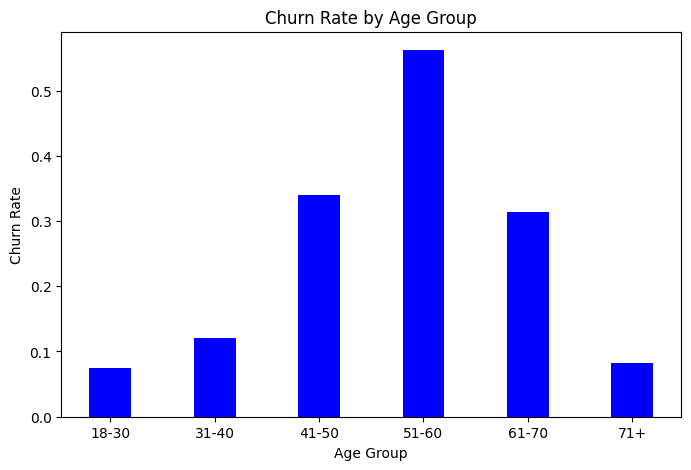

In [50]:
import matplotlib.pyplot as plt
age_churn = df.groupby("age_group")["churn"].mean()
plt.figure(figsize=(8,5))
plt.bar(age_churn.index.astype(str),age_churn.values,color = "blue", width = 0.4)
plt.title('Churn Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Churn Rate')
plt.savefig(r"D:\New folder\churn_by_age.png")
plt.show()

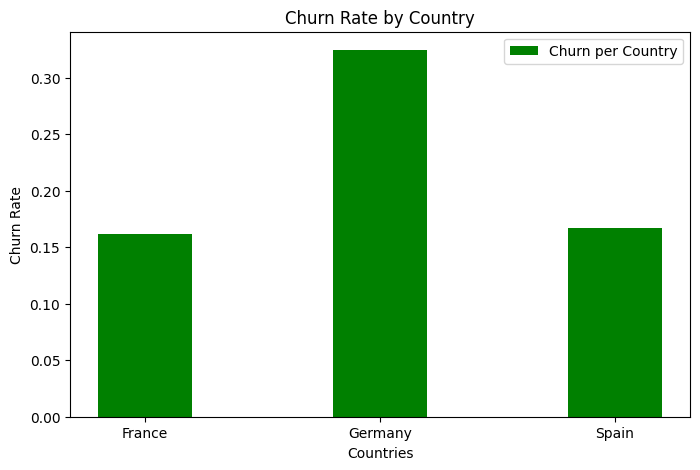

In [55]:
country_churn = df.groupby("country")["churn"].mean()
plt.figure(figsize = (8,5))
plt.bar(country_churn.index, country_churn.values, color='green',width = 0.4,label ='Churn per Country')
plt.title('Churn Rate by Country')
plt.xlabel("Countries")
plt.ylabel('Churn Rate')
plt.legend()
plt.savefig(r'D:\New folder/churn_by_country.png', bbox_inches='tight')
plt.show()

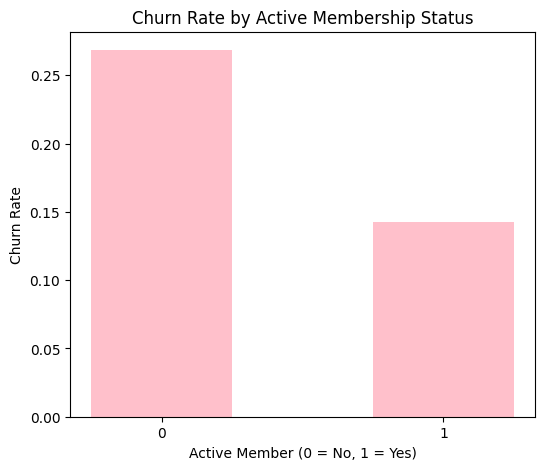

In [57]:
active_churn = df.groupby('active_member')['churn'].mean()

plt.figure(figsize=(6,5))
plt.bar(active_churn.index.astype(str), active_churn.values, color='pink', width = 0.5)
plt.title('Churn Rate by Active Membership Status')
plt.xlabel('Active Member (0 = No, 1 = Yes)')
plt.ylabel('Churn Rate')
plt.savefig(r'D:\New folder/churn_by_active_member.png', bbox_inches='tight')
plt.show()

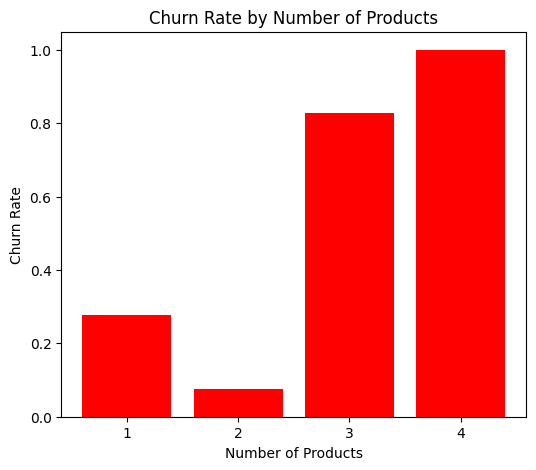

In [58]:
prod_churn = df.groupby('products_number')['churn'].mean()

plt.figure(figsize=(6,5))
plt.bar(prod_churn.index.astype(str), prod_churn.values, color='red')
plt.title('Churn Rate by Number of Products')
plt.xlabel('Number of Products')
plt.ylabel('Churn Rate')
plt.savefig(r'D:\New folder/churn_by_products.png', bbox_inches='tight')
plt.show()

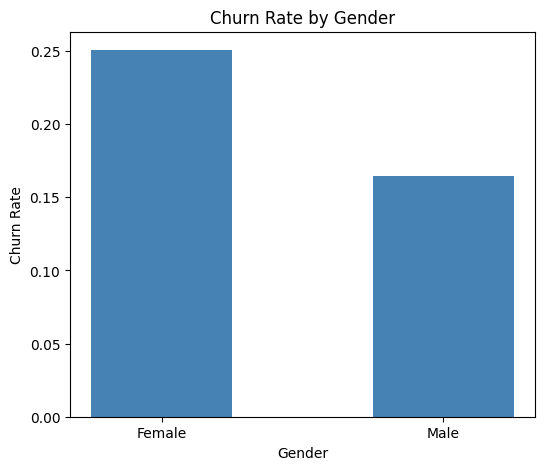

In [60]:
gender_churn = df.groupby('gender')['churn'].mean()

plt.figure(figsize=(6,5))
plt.bar(gender_churn.index, gender_churn.values, color='steelblue', width = 0.5)
plt.title('Churn Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Churn Rate')
plt.savefig(r'D:\New folder/churn_by_gender.png', bbox_inches='tight')
plt.show()

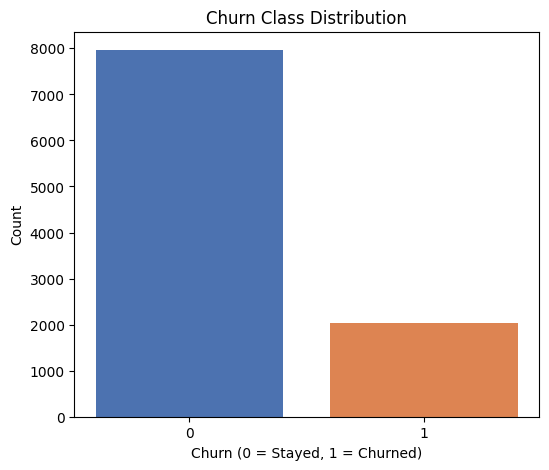

In [61]:
churn_counts = df['churn'].value_counts()

plt.figure(figsize=(6,5))
plt.bar(churn_counts.index.astype(str), churn_counts.values, color=['#4C72B0', '#DD8452'])
plt.title('Churn Class Distribution')
plt.xlabel('Churn (0 = Stayed, 1 = Churned)')
plt.ylabel('Count')
plt.savefig(r'D:\New folder/churn_distribution.png', bbox_inches='tight')
plt.show()

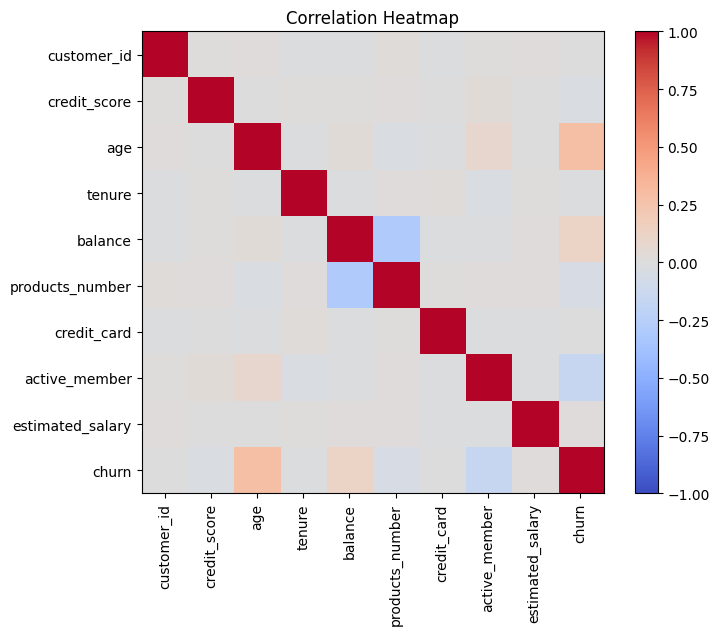

In [65]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(8,6))
plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title('Correlation Heatmap')
plt.savefig(r'D:\New folder/correlation_heatmap.png', bbox_inches='tight')
plt.show()

In [66]:
# FEATURE SELECTION 
df_model = df.drop(columns = ["customer_id"])

In [67]:
df_model = pd.get_dummies(df_model,columns = ["country"],drop_first = True)
df_model["gender"] = df_model["gender"].map({'Male':0,'Female':1})

In [68]:
#Separate features and target
X= df_model.drop(columns = ["churn","age_group"])
y= df_model["churn"]

In [70]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 11, stratify = y)

In [72]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [74]:
print(scaler.mean_)   # shows you the means it learned from X_train, one per column
print(scaler.scale_)  # shows you the standard deviations it learned from X_train

[6.50708875e+02 4.54375000e-01 3.88963750e+01 5.01925000e+00
 7.64957449e+04 1.52675000e+00 7.08000000e-01 5.16375000e-01
 9.96784610e+04 2.50875000e-01 2.49625000e-01]
[9.60206989e+01 4.97914008e-01 1.04989827e+01 2.89039434e+00
 6.23361752e+04 5.77957124e-01 4.54682307e-01 4.99731787e-01
 5.74151328e+04 4.33516706e-01 4.32795979e-01]


In [75]:
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression(random_state = 11)
log_reg.fit(X_train_scaled,y_train)

y_pred = log_reg.predict(X_test_scaled)

In [79]:
print(y_pred[:20])          # first 20 predictions
print(y_pred.sum())          # how many customers predicted to churn
              # model underperdicted the churn, identifying less than half actual churners.
print(y_test.sum())         # how many actually churned (ground truth)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
151
407


In [80]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[1530   63]
 [ 319   88]]
              precision    recall  f1-score   support

           0       0.83      0.96      0.89      1593
           1       0.58      0.22      0.32       407

    accuracy                           0.81      2000
   macro avg       0.71      0.59      0.60      2000
weighted avg       0.78      0.81      0.77      2000



In [81]:
# fix - telling model to pay attention to minority class during training using class_weight = 'balanced'
log_reg_balanced = LogisticRegression(random_state = 11,class_weight = 'balanced')
log_reg_balanced.fit(X_train_scaled ,y_train)

y_pred_balanced = log_reg_balanced.predict(X_test_scaled)

print(confusion_matrix(y_test, y_pred_balanced))
print(classification_report(y_test,y_pred_balanced))

[[1134  459]
 [ 120  287]]
              precision    recall  f1-score   support

           0       0.90      0.71      0.80      1593
           1       0.38      0.71      0.50       407

    accuracy                           0.71      2000
   macro avg       0.64      0.71      0.65      2000
weighted avg       0.80      0.71      0.74      2000



In [82]:
# random forest doesnt need scalar values
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators = 100, random_state = 11)
rf.fit(X_train,y_train)
y_pred_rf = rf.predict(X_test)

print(confusion_matrix(y_test,y_pred_rf))
print(classification_report(y_test,y_pred_rf))
# we can see random forest better than log_reg but we are still missing half of actual 
#churners (201 out of 407) 

[[1534   59]
 [ 201  206]]
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1593
           1       0.78      0.51      0.61       407

    accuracy                           0.87      2000
   macro avg       0.83      0.73      0.77      2000
weighted avg       0.86      0.87      0.86      2000



In [83]:
rf_balanced = RandomForestClassifier(n_estimators = 100, random_state = 11, class_weight = 'balanced')
rf_balanced.fit(X_train,y_train)

y_pred_rf_balanced = rf_balanced.predict(X_test)

print(confusion_matrix(y_test,y_pred_rf_balanced))
print(classification_report(y_test,y_pred_rf_balanced))

[[1539   54]
 [ 211  196]]
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1593
           1       0.78      0.48      0.60       407

    accuracy                           0.87      2000
   macro avg       0.83      0.72      0.76      2000
weighted avg       0.86      0.87      0.85      2000



In [84]:
!python -m pip install xgboost --quiet


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: C:\Users\Divyanshi\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [86]:
from xgboost import XGBClassifier
xgb = XGBClassifier(n_estimators = 100,random_state = 11, eval_metric = 'logloss')
xgb.fit(X_train,y_train)
y_pred_xgb = xgb.predict(X_test)

print(confusion_matrix(y_test,y_pred_xgb))
print(classification_report(y_test,y_pred_xgb))

[[1509   84]
 [ 190  217]]
              precision    recall  f1-score   support

           0       0.89      0.95      0.92      1593
           1       0.72      0.53      0.61       407

    accuracy                           0.86      2000
   macro avg       0.80      0.74      0.76      2000
weighted avg       0.85      0.86      0.85      2000



In [87]:
from sklearn.metrics import roc_auc_score
# use predict_proba as we need actual probabilities not final 0/1 labels
y_prob_log = log_reg.predict_proba(X_test_scaled)[:,1]
y_prob_rf = rf.predict_proba(X_test)[:,1]
y_prob_xgb = xgb.predict_proba(X_test)[:,1]

print("Logistic Regrssion AUC:" , roc_auc_score(y_test,y_prob_log))
print("Random Forest AUC:" , roc_auc_score(y_test,y_prob_rf))
print("XGBoost AUC:" , roc_auc_score(y_test,y_prob_xgb))

Logistic Regrssion AUC: 0.7742966387034184
Random Forest AUC: 0.8635492194814229
XGBoost AUC: 0.8560100932982289


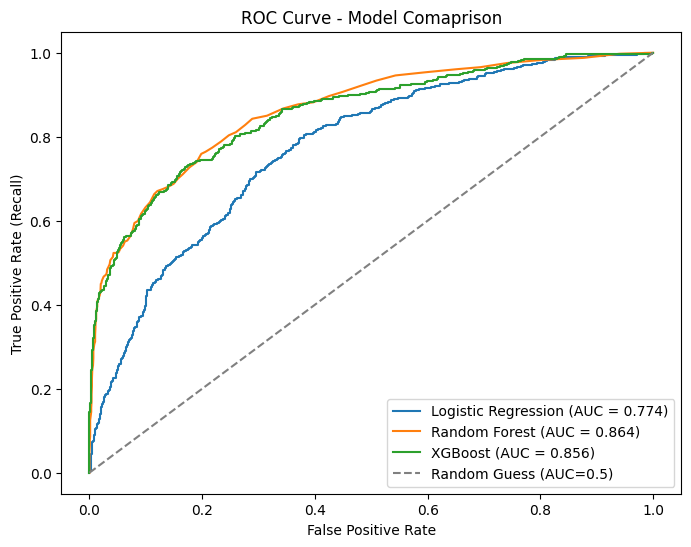

In [91]:
from sklearn.metrics import roc_curve

#get the false positive rate and true positive rate at every threshold
fpr_log,tpr_log,_ = roc_curve(y_test,y_prob_log)
fpr_rf,tpr_rf,_ = roc_curve(y_test,y_prob_rf)
fpr_xgb,tpr_xgb,_ = roc_curve(y_test,y_prob_xgb)

plt.figure(figsize=(8,6))
plt.plot(fpr_log,tpr_log,label = 'Logistic Regression (AUC = 0.774)')
plt.plot(fpr_rf,tpr_rf,label = 'Random Forest (AUC = 0.864)')
plt.plot(fpr_xgb,tpr_xgb, label = 'XGBoost (AUC = 0.856)')
plt.plot([0,1],[0,1],linestyle = '--',color = 'grey',label='Random Guess (AUC=0.5)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve - Model Comaprison')
plt.legend()
plt.savefig(r'D:\New folder/roc_curve_comparison.png', bbox_inches='tight')
plt.show()